# Trabajo Práctico: Predicción de precios de casas

**Aprendizaje Automático 1, Tecnicatura en Inteligencia Artificial (FCEIA)**

Integrantes: Arias, Bousoño, Casariego

Se aborda un problema de regresión sobre el dataset *Boston Housing*: predecir el valor mediano de las
viviendas (`MEDV`, en miles de dólares) a partir de 13 características de la zona.

---

## 1. Análisis descriptivo

### 1.1 Carga e inspección inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('./house-prices-tp.csv', sep=',', encoding='latin-1')

In [3]:
# Los nombres originales son acronimos del censo de Boston, poco legibles en tablas y graficos.
# Se renombran a nombres descriptivos para el resto del trabajo. Se conserva 'B' porque es un indice
# calculado -- B = 1000*(Bk - 0.63)^2 -- que no admite un nombre corto que lo represente fielmente.
nombres = {
    'CRIM': 'criminalidad',          # tasa de criminalidad per capita por ciudad
    'ZN': 'lotes_grandes',           # % de terreno residencial zonificado en lotes de mas de 25.000 pies2
    'INDUS': 'industria',            # % de superficie de negocios no minoristas
    'CHAS': 'limita_rio',            # 1 si la zona limita con el rio Charles, 0 si no
    'NOX': 'contaminacion',          # concentracion de oxidos de nitrogeno (partes por 10 millones)
    'RM': 'habitaciones',            # numero promedio de habitaciones por vivienda
    'AGE': 'viviendas_antiguas',     # % de viviendas ocupadas por su dueno construidas antes de 1940
    'DIS': 'dist_empleo',            # distancia ponderada a cinco centros de empleo de Boston
    'RAD': 'acceso_autopistas',      # indice de accesibilidad a las autopistas radiales
    'TAX': 'impuestos',              # tasa de impuesto inmobiliario por cada 10.000 dolares de valor
    'PTRATIO': 'alumnos_por_docente',# proporcion alumno-maestro por ciudad
    'B': 'B',                        # indice calculado sobre la composicion racial de la ciudad
    'LSTAT': 'pct_estatus_bajo',     # % de poblacion de menor estatus socioeconomico
    'MEDV': 'precio_mediano'         # TARGET: valor mediano de las viviendas, en miles de dolares
}
df = df.rename(columns=nombres)

# Diccionario inverso, para poder mapear contra los nombres de la consigna cuando haga falta.
originales = {v: k for k, v in nombres.items()}

pd.DataFrame({'original': list(nombres.keys()), 'nuevo': list(nombres.values())})

,original,nuevo
0,CRIM,criminalidad
1,ZN,lotes_grandes
2,INDUS,industria
3,CHAS,limita_rio
4,NOX,contaminacion
5,RM,habitaciones
6,AGE,viviendas_antiguas
7,DIS,dist_empleo
8,RAD,acceso_autopistas
9,TAX,impuestos


In [4]:
df.head()

,criminalidad,lotes_grandes,industria,limita_rio,contaminacion,habitaciones,viviendas_antiguas,dist_empleo,acceso_autopistas,impuestos,alumnos_por_docente,B,pct_estatus_bajo,precio_mediano
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   criminalidad         533 non-null    float64
 1   lotes_grandes        534 non-null    float64
 2   industria            541 non-null    float64
 3   limita_rio           533 non-null    float64
 4   contaminacion        532 non-null    float64
 5   habitaciones         535 non-null    float64
 6   viviendas_antiguas   532 non-null    float64
 7   dist_empleo          541 non-null    float64
 8   acceso_autopistas    528 non-null    float64
 9   impuestos            538 non-null    float64
 10  alumnos_por_docente  528 non-null    float64
 11  B                    534 non-null    float64
 12  pct_estatus_bajo     534 non-null    float64
 13  precio_mediano       535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [6]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Dimensiones del dataset: 556 filas x 14 columnas
Memoria utilizada: 0.06 MB


In [7]:
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (14): ['criminalidad', 'lotes_grandes', 'industria', 'limita_rio', 'contaminacion', 'habitaciones', 'viviendas_antiguas', 'dist_empleo', 'acceso_autopistas', 'impuestos', 'alumnos_por_docente', 'B', 'pct_estatus_bajo', 'precio_mediano']
Variables categoricas (0): []


## 1.2 Estadística descriptiva

Se analiza el comportamiento y rango de variación de cada variable antes de tomar cualquier decisión
sobre el dataset.

In [345]:
# Estadisticos descriptivos de todas las variables.
desc = df.describe().T
desc.round(3)

,count,mean,std,min,25%,50%,75%,max
criminalidad,533.0,5.846,13.829,0.006,0.084,0.315,4.871,88.976
lotes_grandes,534.0,13.197,24.903,0.000,0.000,0.000,20.000,100.000
industria,541.0,11.219,6.942,0.460,5.130,9.690,18.100,27.740
limita_rio,533.0,0.090,0.287,0.000,0.000,0.000,0.000,1.000
contaminacion,532.0,0.560,0.119,0.385,0.453,0.538,0.644,0.871
habitaciones,535.0,6.292,0.782,3.561,5.876,6.208,6.639,8.780
viviendas_antiguas,532.0,67.632,28.462,2.900,42.275,76.500,93.825,100.000
dist_empleo,541.0,3.944,2.256,1.130,2.112,3.340,5.401,12.126
acceso_autopistas,528.0,9.699,8.684,1.000,4.000,5.000,23.633,24.000
impuestos,538.0,409.575,167.689,187.000,279.000,335.000,666.000,711.000


In [346]:
# Asimetria y curtosis
forma = pd.DataFrame({'skew': df.skew(), 'kurtosis': df.kurtosis()}).sort_values('skew')
forma.round(2)

,skew,kurtosis
B,-2.40,4.50
alumnos_por_docente,-0.79,-0.30
viviendas_antiguas,-0.55,-1.04
industria,0.30,-1.21
habitaciones,0.37,1.56
impuestos,0.63,-1.17
contaminacion,0.69,-0.23
pct_estatus_bajo,0.95,0.48
acceso_autopistas,0.95,-0.95
precio_mediano,1.06,1.17


In [10]:
# Cantidad de valores distintos por variable: distingue las continuas de las discretas o binarias.
# 'limita_rio' resulta ser la unica binaria y 'acceso_autopistas' toma pocos valores repetidos,
# porque es un atributo de la zona y no de la vivienda individual.
pd.DataFrame({
    'n_unicos': df.nunique(),
    'tipo': df.dtypes.astype(str),
    'ejemplos': [sorted(df[c].dropna().unique())[:5] for c in df.columns]
})

,n_unicos,tipo,ejemplos
criminalidad,531,float64,"[0.00632, 0.00906, 0.01096, 0.01301, 0.01311]"
lotes_grandes,54,float64,"[0.0, 2.8975406840865525, 3.495754219131997, 5..."
industria,111,float64,"[0.46, 0.595217427490333, 0.74, 1.040709024576..."
limita_rio,2,float64,"[0.0, 1.0]"
contaminacion,107,float64,"[0.385, 0.389, 0.392, 0.394, 0.398]"
habitaciones,475,float64,"[3.561, 3.839536135689139, 3.863, 4.0165883793..."
viviendas_antiguas,382,float64,"[2.9, 6.0, 6.2, 6.5, 6.6]"
dist_empleo,447,float64,"[1.1296, 1.137, 1.1691, 1.1742, 1.1781]"
acceso_autopistas,31,float64,"[1.0, 1.3071276337271132, 2.0, 2.4024241854367..."
impuestos,98,float64,"[187.0, 188.0, 193.0, 197.236588131949, 198.0]"


## 1.3 Análisis de datos faltantes

La consigna pide analizar y **decidir** sobre los datos faltantes. Antes de elegir entre imputar o
eliminar, hay que entender *qué* falta y *por qué*: la herramienta correcta depende del mecanismo
que generó la ausencia.

In [11]:
# Conteo y porcentaje de faltantes por variable.
nulos = pd.DataFrame({
    'n_nulos': df.isna().sum(),
    'pct': (100 * df.isna().mean()).round(2)
}).sort_values('n_nulos', ascending=False)

print(f'Celdas faltantes totales: {df.isna().sum().sum()} de {df.size} '
      f'({100 * df.isna().sum().sum() / df.size:.2f}%)')
nulos

Celdas faltantes totales: 306 de 7784 (3.93%)


,n_nulos,pct
alumnos_por_docente,28,5.04
acceso_autopistas,28,5.04
contaminacion,24,4.32
viviendas_antiguas,24,4.32
limita_rio,23,4.14
criminalidad,23,4.14
pct_estatus_bajo,22,3.96
B,22,3.96
lotes_grandes,22,3.96
habitaciones,21,3.78


In [12]:
# Los faltantes estan repartidos de forma pareja entre columnas (15 a 28 cada una), pero interesa
# saber como se distribuyen ENTRE FILAS: si la ausencia de datos esta dispersa o concentrada en pocos registros.
nulos_por_fila = df.isna().sum(axis=1)

print(f'Filas con al menos un faltante : {(nulos_por_fila > 0).sum()} de {len(df)}')
print(f'Filas sin ningun faltante      : {(nulos_por_fila == 0).sum()}')
print(f'Faltantes promedio en las filas afectadas: '
      f'{nulos_por_fila[nulos_por_fila > 0].mean():.1f} de {df.shape[1]} columnas')
print()
print('El problema no esta disperso: afecta a pocas filas y en cada una alcanza a casi la mitad de las')
print('columnas. La unidad del problema es la FILA, no la celda.')
print()
print('Distribucion de faltantes por fila:')
nulos_por_fila.value_counts().sort_index()


Filas con al menos un faltante : 50 de 556
Filas sin ningun faltante      : 506
Faltantes promedio en las filas afectadas: 6.1 de 14 columnas

Distribucion de faltantes por fila:


0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1
Name: count, dtype: int64

### Diagnóstico de las filas afectadas

Los faltantes se concentran en 50 filas enteras, así que la decisión se toma fila por fila. Se avanza por
etapas: en cada una se descarta únicamente lo que la evidencia disponible en ese momento permite
descartar, y se deja el resto en observación.

In [ ]:
# El primer descarte no requiere ningun analisis: una fila sin variable objetivo no puede intervenir
# en el ajuste de un modelo supervisado, e imputar el target seria fabricar la variable a predecir.
sin_target = df['precio_mediano'].isna()
df_t = df[~sin_target]

print(f'Filas sin precio_mediano : {sin_target.sum()}  -> se eliminan')
print(f'Dataset restante         : {len(df_t)} filas')
print(f'Filas con nulos que aun quedan: {df_t.isna().any(axis=1).sum()}')

In [ ]:
# Como quedaron repartidos los faltantes en las filas que sobrevivieron.
nulos_fila = df_t.isna().sum(axis=1)
afectadas = nulos_fila[nulos_fila > 0]

fig, ax = plt.subplots(figsize=(8, 4))
conteo = afectadas.value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Columnas nulas en la fila (de 14)')
ax.set_ylabel('Cantidad de filas')
ax.set_title(f'Faltantes por fila en las {len(afectadas)} filas afectadas restantes')
ax.set_xticks(range(1, int(afectadas.max()) + 1))
plt.tight_layout()
plt.show()

print(f'Las filas mas incompletas del dataset se fueron con el filtro anterior: el maximo actual es de '
      f'{afectadas.max()} columnas nulas.')

Quedan 29 filas con entre 1 y 9 columnas ausentes. A simple vista podrían ser observaciones
incompletas normales, así que antes de decidir sobre ellas se buscan errores de carga evidentes.

In [ ]:
# Primera verificacion: valores fuera del dominio de cada variable. Las proporciones y porcentajes
# solo admiten valores entre 0 y 100, ninguna magnitud del problema puede ser negativa y 'limita_rio'
# es una dummy. Un valor fuera de esos limites seria un error de carga y se eliminaria sin discusion.
porcentajes = ['lotes_grandes', 'viviendas_antiguas', 'industria', 'pct_estatus_bajo']
no_negativas = [c for c in df_t.columns if c != 'limita_rio']

fuera_rango = {c: (~df_t[c].dropna().between(0, 100)).sum() for c in porcentajes}
negativos   = {c: (df_t[c].dropna() < 0).sum() for c in no_negativas}
no_binarios = (~df_t['limita_rio'].dropna().isin([0, 1])).sum()

print(f'Porcentajes fuera del intervalo [0, 100] : {sum(fuera_rango.values())}')
print(f'Valores negativos en variables positivas : {sum(negativos.values())}')
print(f'Valores no binarios en limita_rio        : {no_binarios}')
print()
print('No hay errores de carga: todos los valores son admisibles para su variable.')
print('No se elimina ninguna fila en este paso.')

In [ ]:
# Segunda verificacion: registros repetidos, que inflarian artificialmente el peso de una observacion.
print(f'Duplicados exactos            : {df_t.duplicated().sum()}')
print(f'Duplicados entre filas incompletas: {df_t[df_t.isna().any(axis=1)].duplicated().sum()}')
print()
print('Tampoco hay duplicados. Las 29 filas siguen sin motivo para ser descartadas.')

Ninguna de las dos verificaciones encontró nada. Si estas filas fueran problemáticas, el motivo no
está en valores imposibles ni en repeticiones, así que se pasa a comparar su comportamiento con el
del resto del dataset.

In [ ]:
# Se separan los dos grupos y se comparan sus distribuciones. Para poder mirar las 14 variables en un
# mismo eje se estandarizan usando la media y el desvio del grupo completo: cada punto queda expresado
# en desvios respecto de lo tipico del dataset.
incompletas = df_t[df_t.isna().any(axis=1)]
completo    = df_t[~df_t.isna().any(axis=1)]

z_comp = (completo    - completo.mean()) / completo.std()
z_inc  = (incompletas - completo.mean()) / completo.std()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=z_comp, ax=ax, color='lightsteelblue', fliersize=2)
for j, var in enumerate(df_t.columns):
    v = z_inc[var].dropna()
    ax.scatter(np.full(len(v), j) + np.random.uniform(-0.15, 0.15, len(v)),
               v, color='crimson', s=18, zorder=3, label='filas incompletas' if j == 0 else None)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_title('Filas incompletas (rojo) sobre la distribucion del grupo completo (cajas)')
ax.set_ylabel('Desvios estandar respecto del grupo completo')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# El grafico sugiere que las filas incompletas se ubican de manera distinta, pero conviene cuantificarlo.
# Se comparan las medianas contra el rango observado en el grupo completo.
pd.DataFrame({
    'mediana_completo': completo.median(),
    'mediana_incompletas': incompletas.median(),
    'min_completo': completo.min(),
    'max_completo': completo.max(),
    'n_presentes': incompletas.notna().sum()
}).round(2)

Las medianas se desplazan de forma llamativa (`criminalidad` pasa de 0.26 a valores un orden de
magnitud mayores), pero el argumento es débil: se calculan sobre 12 a 19 valores, y con esa cantidad
de datos una diferencia así puede aparecer por azar. No alcanza para eliminar nada.

La pista aparece al mirar los valores tal como están escritos en el archivo, en lugar de sus
estadísticos.

In [ ]:
# Cada variable del dataset esta registrada con una precision fija y propia: la criminalidad siempre
# con 5 decimales, la contaminacion con 3, los impuestos como enteros. Es la firma de un dato medido y
# volcado con una convencion. Se cuenta cuantos decimales tiene cada valor tal como figura en el CSV,
# releyendo el archivo como texto para no confundir la precision escrita con la del tipo float.
crudo = pd.read_csv('./house-prices-tp.csv', sep=',', encoding='latin-1', dtype=str)
crudo.columns = df.columns
crudo = crudo.loc[df_t.index]

def n_decimales(x):
    if not isinstance(x, str) or x.strip() == '':
        return np.nan
    return len(x.split('.')[1]) if '.' in x else 0

dec = crudo.map(n_decimales)
es_incompleta = df_t.isna().any(axis=1)

pd.DataFrame({
    'dec_max_completo': dec[~es_incompleta].max(),
    'dec_max_incompletas': dec[es_incompleta].max(),
    'dec_moda_completo': dec[~es_incompleta].mode().iloc[0],
    'dec_moda_incompletas': dec[es_incompleta].mode().iloc[0]
}).astype('Int64')

In [ ]:
# La diferencia es tan marcada que conviene verla de un vistazo.
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_t.columns))
ax.bar(x - 0.2, dec[~es_incompleta].max(), 0.4, label='filas completas',   color='steelblue')
ax.bar(x + 0.2, dec[es_incompleta].max(), 0.4, label='filas incompletas', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(df_t.columns, rotation=45, ha='right')
ax.set_ylabel('Decimales (maximo observado)')
ax.set_title('Precision con la que esta escrito cada valor')
ax.legend()
plt.tight_layout()
plt.show()

print('Las filas completas respetan una convencion distinta por variable (entre 1 y 5 decimales).')
print('Las incompletas usan 13 a 17 decimales en todas, salvo en la unica variable binaria.')

In [ ]:
# Se verifica que la anomalia coincida exactamente con los faltantes y no sea un fenomeno aparte.
# Se considera anomala toda fila con al menos un valor de mas de 6 decimales.
anomala = (dec > 6).any(axis=1)

print(pd.crosstab(es_incompleta, anomala,
                  rownames=['tiene nulos'], colnames=['precision anomala']).to_string())
print()
print(f'Celdas de precision normal dentro de filas incompletas: '
      f'{((dec >= 0) & (dec <= 6) & es_incompleta.values[:, None]).sum().sum()}, '
      f'todas de limita_rio (binaria: 0 o 1 no admite decimales).')

La correspondencia entre faltantes y precisión anómala es exacta, pero eso todavía no dice de dónde
salen estas filas. Una explicación posible es que provengan de otra fuente: un relevamiento distinto,
hecho con otro instrumento o volcado con otro criterio, que se juntó con el original en un mismo
archivo. Que dos orígenes convivan en una tabla no es raro.

Lo que llama la atención es la **cantidad** de dígitos. No son uno o dos decimales de más, que sería
lo esperable de un instrumento más fino: son entre 13 y 17, en todas las variables no binarias a la
vez. Ninguna medición de un porcentaje, una distancia o un precio inmobiliario se registra con esa
precisión.

La hipótesis de la segunda fuente merece tomarse en serio antes de descartar nada, porque de ser
cierta habría información aprovechable. Se analizan entonces las 29 filas restantes con más detalle.

### Intento de rescate

Las 29 filas son el 5,4% de los 535 registros con target. Con un dataset de este tamaño no sobra
nada, así que antes de descartarlas corresponde preguntarse qué parte se puede aprovechar: los
controles de dominio y de duplicados no encontraron nada roto, y muchas de estas filas conservan
buena parte de sus columnas.

El criterio razonable es quedarse con aquellas cuyos **predictores más informativos** estén
presentes: si a una fila le falta una variable poco relacionada con el precio, perderla cuesta poco;
si le falta la que más pesa, no hay nada que hacer. Se determina cuáles son con los datos, en lugar
de suponerlo, y se elige una exigencia baja a propósito: la idea es rescatar todo lo que se pueda, no
buscar una excusa para descartar.

In [ ]:
# Fuerza de cada variable como predictor, medida sobre las 506 filas completas (las unicas
# confiables para estimarla).
corr_target = completo.corr()['precio_mediano'].drop('precio_mediano')
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
orden = corr_target.index.tolist()

print('Correlacion con el target:')
print(corr_target.round(3).to_string())

In [ ]:
# Cuanto mas exigente el criterio, menos filas sobreviven. Se mira la relacion completa antes de
# fijar el umbral, para no elegirlo de forma arbitraria.
curva = pd.DataFrame({
    'k': range(1, 7),
    'predictores_exigidos': [', '.join(orden[:k]) for k in range(1, 7)],
    'filas_rescatables': [int(incompletas[orden[:k]].notna().all(axis=1).sum()) for k in range(1, 7)]
}).set_index('k')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curva.index, curva.filas_rescatables, 'o-', color='steelblue')
ax.axhline(len(incompletas), color='grey', lw=0.8, ls='--')
ax.set_xlabel('Predictores exigidos (los k mas correlacionados con el precio)')
ax.set_ylabel('Filas rescatables')
ax.set_ylim(0, len(incompletas) + 1)
ax.set_title(f'Filas rescatables segun cuan exigente sea el criterio (de {len(incompletas)})')
plt.tight_layout()
plt.show()

curva

In [ ]:
# Entre la segunda variable (habitaciones, 0.70) y la tercera (0.51) hay un salto claro, asi que el
# corte natural son las dos primeras. Es tambien el criterio mas permisivo que sigue teniendo sentido:
# exigir menos seria aceptar filas sin ninguna variable realmente informativa.
fuertes = orden[:2]
candidatas = incompletas[incompletas[fuertes].notna().all(axis=1)]

print(f'Predictores exigidos    : {fuertes}')
print(f'Filas que los conservan : {len(candidatas)} de {len(incompletas)} '
      f'({100 * len(candidatas) / len(incompletas):.0f}%)')

Sobrevive más de la mitad: 16 de las 29. El criterio deja pasar bastante, que es lo que se buscaba.

### Coherencia de los registros rescatados

Tener predictores no alcanza. Falta revisar algo que hasta ahora no se había mirado: si lo que
dicen estas filas es coherente, empezando por su **valor a predecir**. Una fila sin predictores es
inservible, pero una fila con un target inventado es peor, porque el modelo la toma como verdad y
ajusta hacia ella.

In [ ]:
# Se aplica al target la misma lectura de precision que se uso con los predictores.
dec_target = dec['precio_mediano']

print(f'Decimales del target en las 506 completas : max {int(dec_target[~es_incompleta].max())}, '
      f'moda {int(dec_target[~es_incompleta].mode().iloc[0])}')
print(f'Decimales del target en las 29 incompletas: min {int(dec_target[es_incompleta].min())}, '
      f'max {int(dec_target[es_incompleta].max())}')
print()
print('Primeros valores de precio_mediano, tal como figuran en el archivo:')
print(pd.DataFrame({
    'completas': crudo.loc[~es_incompleta, 'precio_mediano'].head(5).values,
    'incompletas': crudo.loc[es_incompleta, 'precio_mediano'].head(5).values
}).to_string(index=False))

In [ ]:
# Si el target fuera real, la relacion entre predictores y precio deberia sostenerse tambien dentro
# de estas filas. Se compara la correlacion en cada grupo, usando en cada variable los pares
# disponibles.
filas = []
for v in orden[:6]:
    sub = incompletas[[v, 'precio_mediano']].dropna()
    filas.append({'variable': v,
                  'corr_en_506': completo[v].corr(completo['precio_mediano']),
                  'corr_en_29': sub[v].corr(sub['precio_mediano']),
                  'n_pares': len(sub)})
pd.DataFrame(filas).set_index('variable').round(3)

In [ ]:
# Prueba directa: un modelo lineal entrenado con las 506 filas confiables, evaluado sobre las 29.
# Los faltantes se completan con la mediana para poder predecir.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_comp = completo.drop(columns='precio_mediano')
modelo = LinearRegression().fit(X_comp, completo['precio_mediano'])

X_inc = incompletas.drop(columns='precio_mediano').fillna(X_comp.median())
pred = modelo.predict(X_inc)
real = incompletas['precio_mediano'].values

print(f'R2 sobre las 506 de entrenamiento : {modelo.score(X_comp, completo["precio_mediano"]):.3f}')
print(f'R2 sobre las 29 incompletas       : {r2_score(real, pred):.3f}')
print(f'Correlacion entre predicho y real : {np.corrcoef(pred, real)[0, 1]:.3f}')
print()
print('Un R2 negativo significa que predecir siempre el promedio acierta mas que el modelo.')

In [ ]:
# El R2 es un promedio y podria estar escondiendo filas individuales aprovechables. Se revisa una por
# una, ordenando por que tan lejos quedo la prediccion del valor registrado.
detalle = pd.DataFrame({
    'nulos': incompletas.isna().sum(axis=1),
    'precio_real': incompletas['precio_mediano'],
    'precio_predicho': pd.Series(pred, index=incompletas.index)
})
detalle['error'] = (detalle['precio_real'] - detalle['precio_predicho']).abs()

error_medio = np.abs(completo['precio_mediano'] - modelo.predict(X_comp)).mean()
print(f'Error absoluto medio del modelo sobre las 506 de entrenamiento: {error_medio:.2f}')

detalle.sort_values('error').round(1)

La columna `error` muestra variación. Tres filas quedan a menos de una unidad de la predicción,
mientras otras se van a más de 30, contra un error típico de 3.3 en las filas de entrenamiento. Varias
predicciones dan negativas (precios imposibles) porque sus combinaciones de variables no aparecen en
el dataset real.

Podría pensarse en conservar las de error chico. No corresponde, por dos razones. La primera es que
con 29 valores arbitrarios algunos van a caer cerca por azar, y eso es lo que se observa. La segunda
es que el criterio sería circular: para saber qué filas tienen error chico hace falta conocer el
precio verdadero, que es justamente lo que el modelo debe predecir. Seleccionarlas equivale a
quedarse sólo con los casos que ya coinciden con lo que el modelo estima, lo que no aporta
información nueva y sesga la evaluación.

In [ ]:
# Ultimo control sobre las filas candidatas: coherencia entre variables. En el grupo completo, las
# zonas con mucha poblacion de estatus bajo no tienen viviendas grandes, y las viviendas grandes no
# son baratas.
print(candidatas[orden[:6] + ['precio_mediano']].round(2).to_string())
print()
rango_rm = completo.loc[completo.pct_estatus_bajo > 30, 'habitaciones']
print(f'De las 506 filas completas, con pct_estatus_bajo > 30 las habitaciones van de '
      f'{rango_rm.min():.2f} a {rango_rm.max():.2f} (n={len(rango_rm)}): ninguna supera 7.5.')

precio_rm = completo.loc[completo.habitaciones > 8, 'precio_mediano']
print(f'De las 506, con habitaciones > 8 el precio va de {precio_rm.min():.1f} a '
      f'{precio_rm.max():.1f} (n={len(precio_rm)}).')
print()
print('Entre las candidatas hay filas que violan ambos patrones a la vez.')

### Decisión sobre los datos faltantes

El intento de rescate falla en las tres condiciones que debía cumplir.

**Los predictores no alcanzan.** El criterio se fijó deliberadamente bajo (basta con conservar las dos
variables más correlacionadas con el precio) y aun así 13 de las 29 filas no lo pasan. Sobreviven 16.

**El target tampoco es real.** Los precios de las 506 filas completas están escritos con un decimal,
la convención con la que se registró el dataset. Los de las 29 tienen entre 14 y 15. El valor a
predecir de estas filas no fue observado: fue generado, igual que sus predictores.

**La relación entre variables no existe dentro de ellas.** `habitaciones` correlaciona +0.70 con el
precio en las 506 filas completas y cambia de signo dentro de las 29; `pct_estatus_bajo` pasa de
-0.74 a prácticamente cero. Un modelo entrenado con las filas confiables obtiene R² negativo sobre
ellas: predecir el promedio acierta más. Y entre las 16 candidatas aparecen combinaciones que el
dataset real no produce nunca: una zona con 36% de población de estatus bajo y 8 habitaciones
promedio por vivienda, u otra con 8 habitaciones promedio valuada en 18 mil dólares cuando ninguna
zona real con viviendas así baja de 21.9.

**La hipótesis de la segunda fuente queda descartada.** Un origen distinto explica *cómo* se escribe
un dato, no *qué dice*: otro instrumento cambia la precisión, pero no invierte la relación entre el
tamaño de las viviendas y su precio, ni produce barrios que en el dataset real no existen. Y aun si
fuera una fuente legítima, mezclar dos poblaciones con comportamientos distintos degradaría el
modelo en lugar de mejorarlo.

Se eliminan las 29 filas. **No se imputan**: imputar sirve cuando el resto de la fila es información
válida y sólo faltan algunas celdas, pero acá los valores presentes provienen del mismo proceso que
generó los ausentes (ninguna de las 377 celdas presentes en estas filas respeta la precisión del
dataset) y el target al que se ajustaría el modelo es inventado. Conservarlas no agrega datos: agrega
ruido con etiqueta.

In [ ]:
# Se descartan las filas incompletas restantes y se consolida el conjunto de trabajo.
df_limpio = df_t[~df_t.isna().any(axis=1)].reset_index(drop=True)

print(f'Dataset original : {df.shape[0]} filas')
print(f'  - sin target   : {sin_target.sum()}')
print(f'  - incompletas  : {len(incompletas)}')
print(f'Dataset limpio   : {df_limpio.shape[0]} filas x {df_limpio.shape[1]} columnas '
      f'({100 * (df.shape[0] - df_limpio.shape[0]) / df.shape[0]:.1f}% eliminado)')
print(f'Faltantes restantes: {df_limpio.isna().sum().sum()}')
print(f'Duplicados exactos : {df_limpio.duplicated().sum()}')

In [21]:
# Efecto de la limpieza sobre la senal: al quitar el ruido las correlaciones con el target se refuerzan.
comparacion = pd.DataFrame({
    'corr_antes': df.corr()['precio_mediano'].drop('precio_mediano'),
    'corr_despues': df_limpio.corr()['precio_mediano'].drop('precio_mediano')
})
comparacion['mejora_abs'] = comparacion['corr_despues'].abs() - comparacion['corr_antes'].abs()
comparacion.round(3).sort_values('mejora_abs', ascending=False)

,corr_antes,corr_despues,mejora_abs
criminalidad,-0.228,-0.388,0.160
habitaciones,0.588,0.695,0.107
pct_estatus_bajo,-0.653,-0.738,0.085
contaminacion,-0.361,-0.427,0.067
industria,-0.419,-0.484,0.065
B,0.270,0.333,0.063
acceso_autopistas,-0.342,-0.382,0.039
alumnos_por_docente,-0.475,-0.508,0.033
impuestos,-0.438,-0.469,0.031
dist_empleo,0.223,0.250,0.027


## 1.4 Visualización de los datos

Todas las visualizaciones se realizan sobre el conjunto limpio.

In [22]:
# Estadistica descriptiva del conjunto limpio, que es la que describe realmente el problema.
df_limpio.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
criminalidad,506.0,3.614,8.602,0.006,0.082,0.257,3.677,88.976
lotes_grandes,506.0,11.364,23.322,0.000,0.000,0.000,12.500,100.000
industria,506.0,11.137,6.860,0.460,5.190,9.690,18.100,27.740
limita_rio,506.0,0.069,0.254,0.000,0.000,0.000,0.000,1.000
contaminacion,506.0,0.555,0.116,0.385,0.449,0.538,0.624,0.871
habitaciones,506.0,6.285,0.703,3.561,5.885,6.208,6.624,8.780
viviendas_antiguas,506.0,68.575,28.149,2.900,45.025,77.500,94.075,100.000
dist_empleo,506.0,3.795,2.106,1.130,2.100,3.207,5.188,12.126
acceso_autopistas,506.0,9.549,8.707,1.000,4.000,5.000,24.000,24.000
impuestos,506.0,408.237,168.537,187.000,279.000,330.000,666.000,711.000


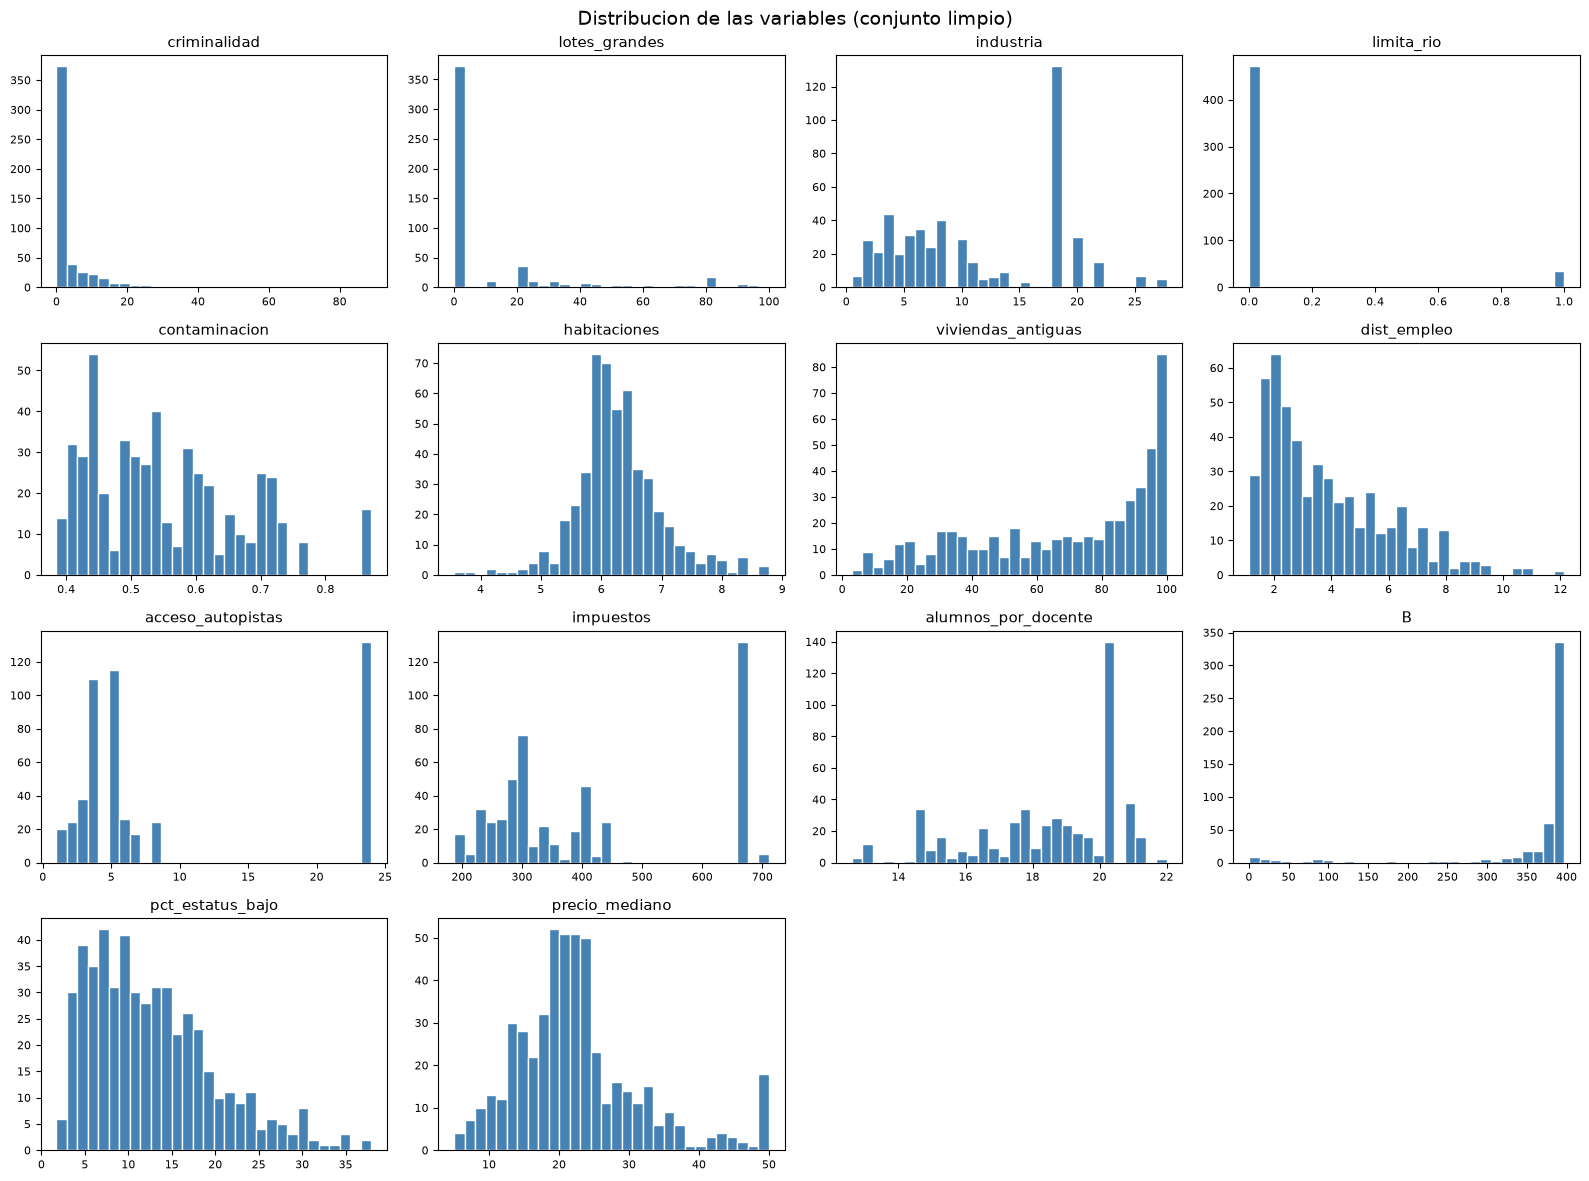

In [23]:
# Histogramas de todas las variables: muestran la forma de cada distribucion y su rango de variacion.
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, var in zip(axes.flat, df_limpio.columns):
    ax.hist(df_limpio[var], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(var, fontsize=11)
    ax.tick_params(labelsize=8)
for ax in axes.flat[df_limpio.shape[1]:]:
    ax.set_visible(False)
fig.suptitle('Distribucion de las variables (conjunto limpio)', fontsize=14)
plt.tight_layout()
plt.show()

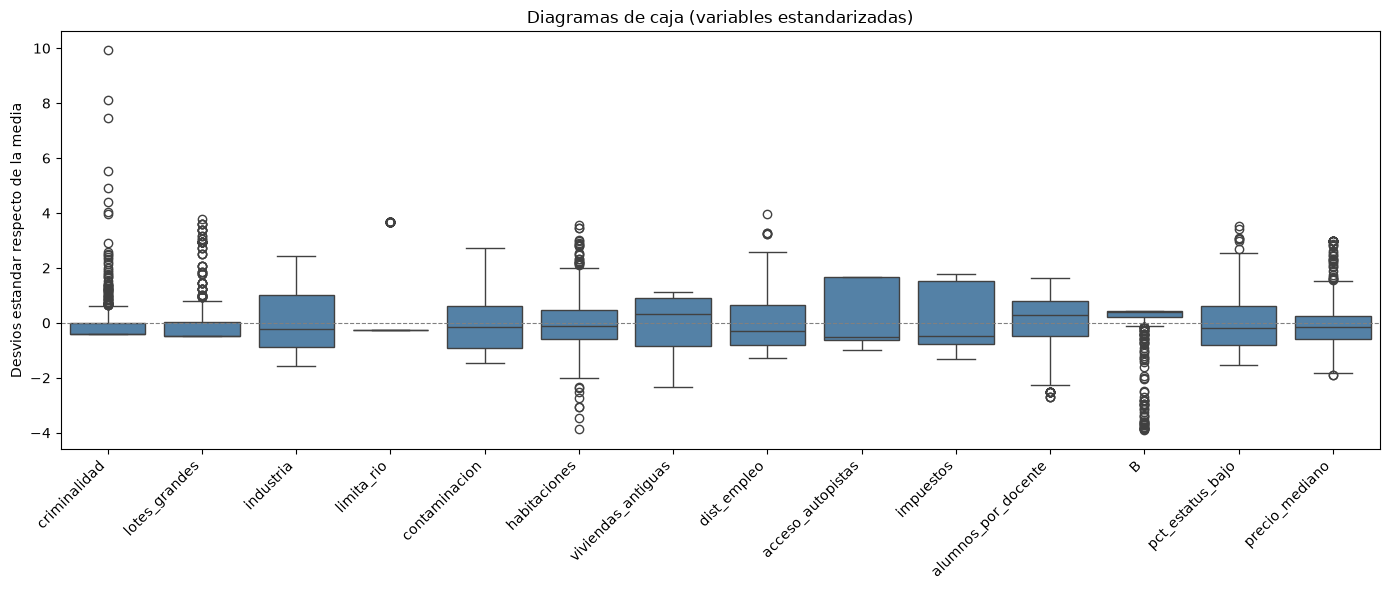

In [24]:
# Diagramas de caja sobre variables estandarizadas, para poder compararlas en un mismo eje pese a
# tener escalas muy distintas (los impuestos estan en cientos y la contaminacion en decimas).
df_z = (df_limpio - df_limpio.mean()) / df_limpio.std()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_z, ax=ax, color='steelblue')
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_title('Diagramas de caja (variables estandarizadas)')
ax.set_ylabel('Desvios estandar respecto de la media')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Los valores extremos que muestran los boxplots son datos reales (zonas de alta criminalidad, lotes
# grandes), no errores de carga. Se cuantifica cuantas filas eliminaria una regla IQR ciega para
# justificar la decision de NO aplicarla.
q1, q3 = df_limpio.quantile(0.25), df_limpio.quantile(0.75)
iqr = q3 - q1
fuera = (df_limpio < q1 - 1.5 * iqr) | (df_limpio > q3 + 1.5 * iqr)

print('Filas marcadas como atipicas por variable:')
print(fuera.sum()[fuera.sum() > 0].sort_values(ascending=False).to_string())
print()
print(f'Filas que eliminaria la regla 1.5*IQR aplicada a cualquier variable: '
      f'{fuera.any(axis=1).sum()} de {len(df_limpio)} ({100 * fuera.any(axis=1).mean():.1f}%)')
print('Se descarta esa regla: eliminaria casi la mitad del dataset y con ella la senal del problema.')

Filas marcadas como atipicas por variable:
B                      77
lotes_grandes          68
criminalidad           66
precio_mediano         40
limita_rio             35
habitaciones           30
alumnos_por_docente    15
pct_estatus_bajo        7
dist_empleo             5

Filas que eliminaria la regla 1.5*IQR aplicada a cualquier variable: 238 de 506 (47.0%)
Se descarta esa regla: eliminaria casi la mitad del dataset y con ella la senal del problema.


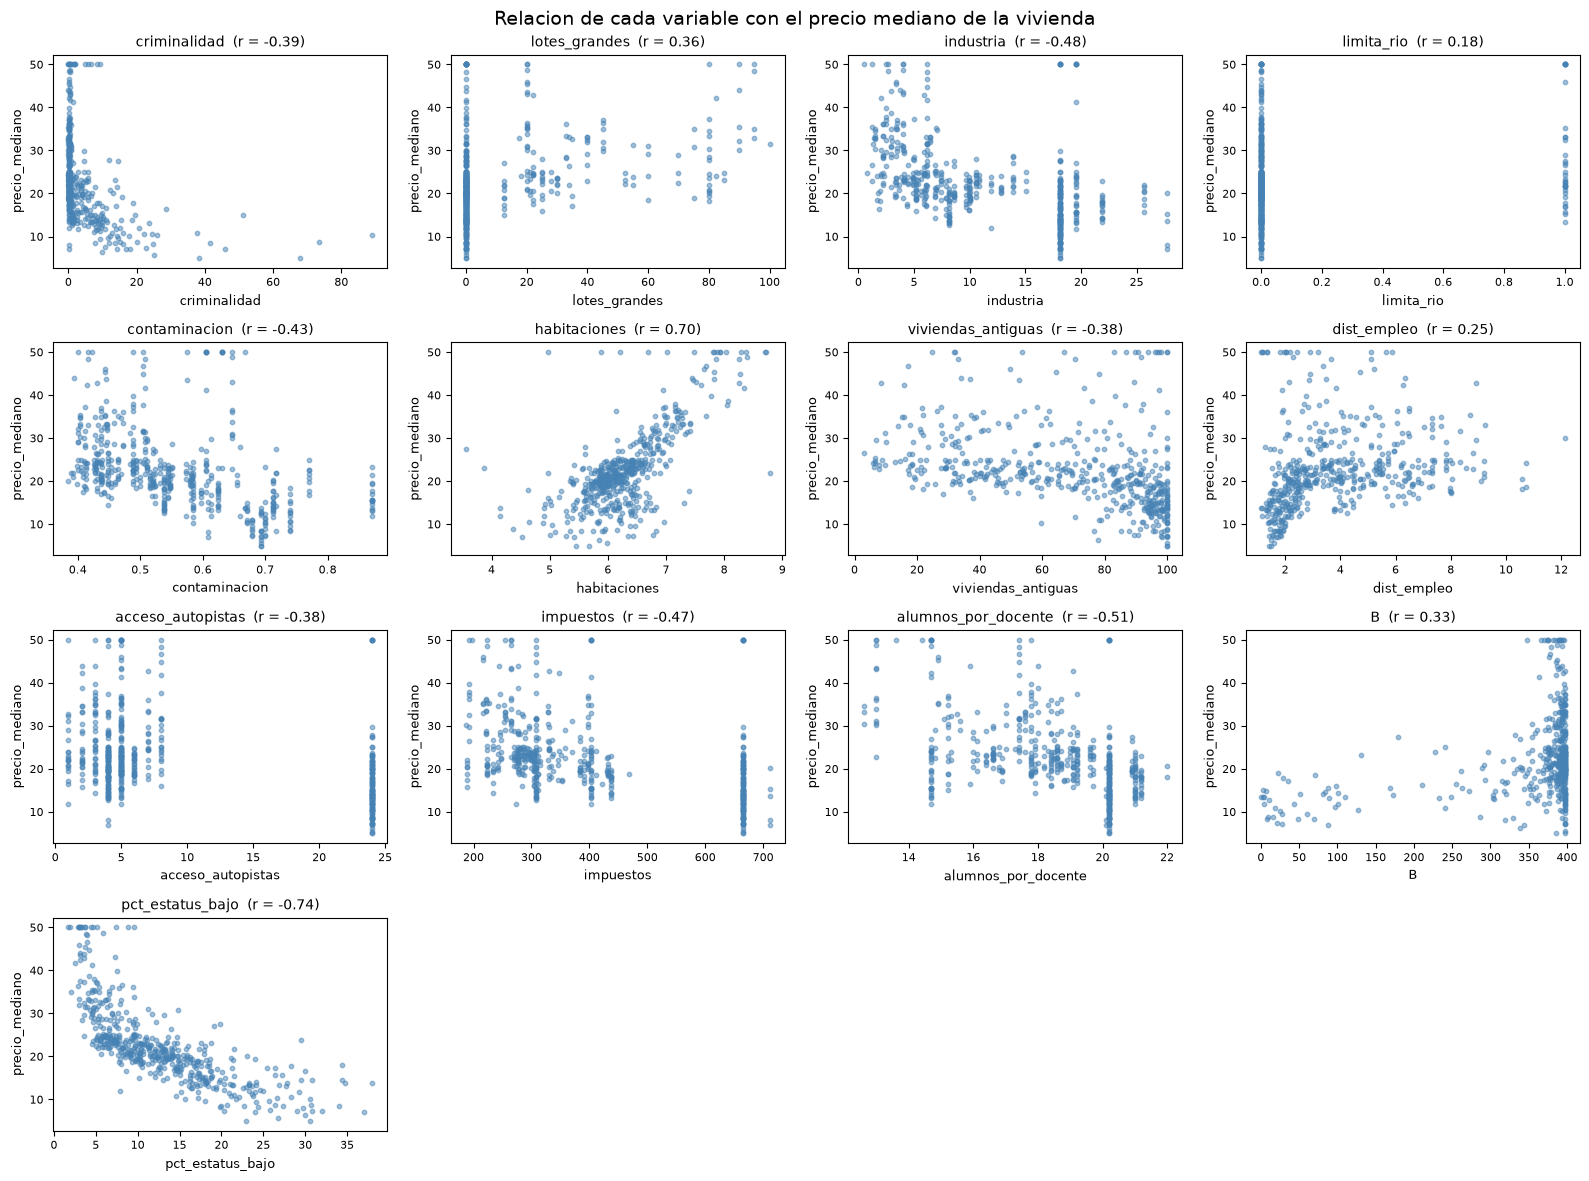

In [26]:
# Relacion de cada variable con el target. Se busca identificar cuales presentan relacion lineal con
# el precio y cuales no, ya que la linealidad es el supuesto sobre el que se construira el modelo.
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
predictoras = [c for c in df_limpio.columns if c != 'precio_mediano']
for ax, var in zip(axes.flat, predictoras):
    ax.scatter(df_limpio[var], df_limpio['precio_mediano'], s=10, alpha=0.5, color='steelblue')
    r = df_limpio[var].corr(df_limpio['precio_mediano'])
    ax.set_title(f'{var}  (r = {r:.2f})', fontsize=10)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('precio_mediano', fontsize=9)
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(predictoras):]:
    ax.set_visible(False)
fig.suptitle('Relacion de cada variable con el precio mediano de la vivienda', fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Matriz de correlación

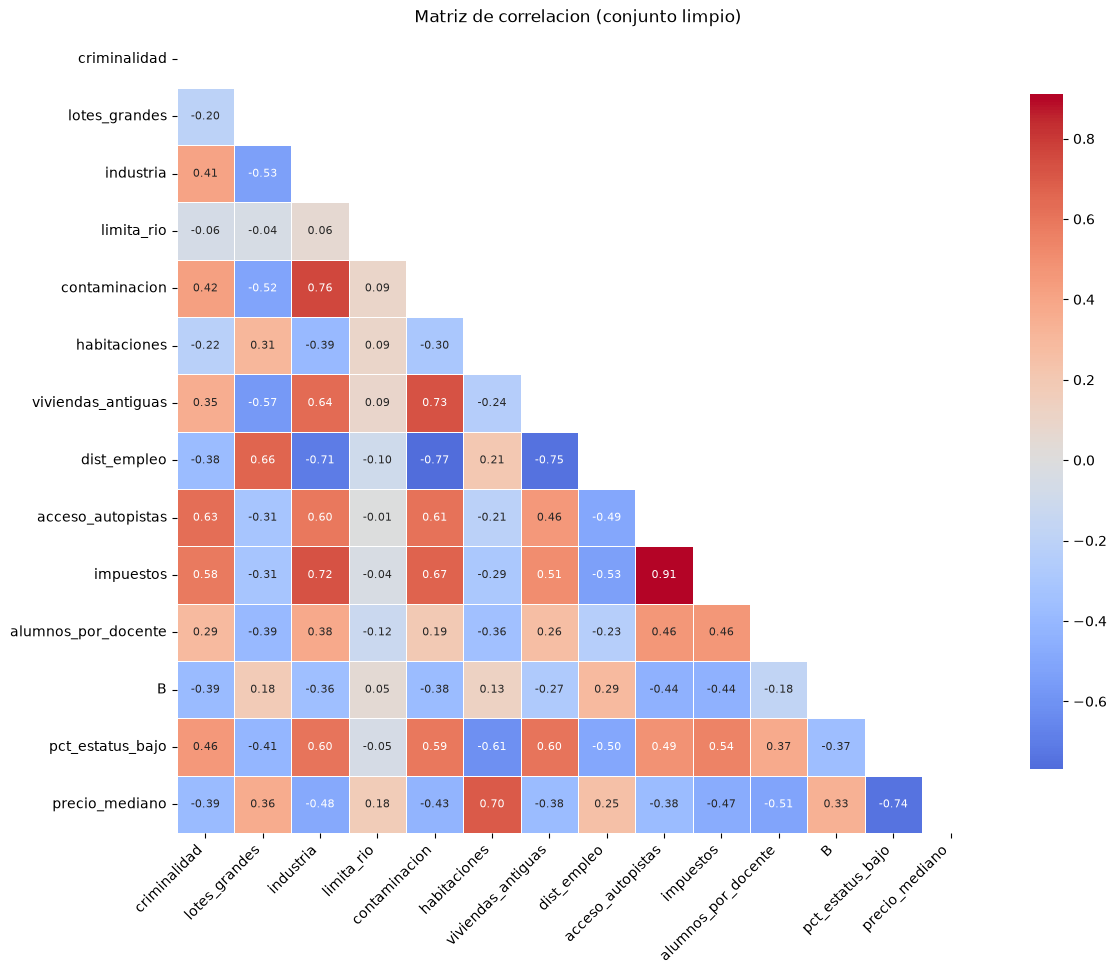

In [27]:
# Matriz de correlacion de Pearson entre todas las variables.
corr = df_limpio.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}, ax=ax)
ax.set_title('Matriz de correlacion (conjunto limpio)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

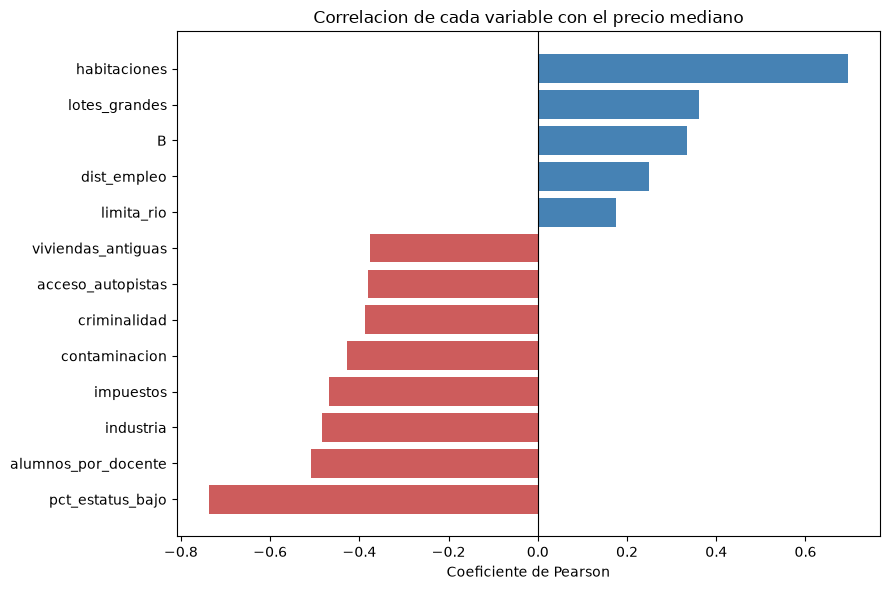

pct_estatus_bajo      -0.738
alumnos_por_docente   -0.508
industria             -0.484
impuestos             -0.469
contaminacion         -0.427
criminalidad          -0.388
acceso_autopistas     -0.382
viviendas_antiguas    -0.377
limita_rio             0.175
dist_empleo            0.250
B                      0.333
lotes_grandes          0.360
habitaciones           0.695
Name: precio_mediano, dtype: float64

In [28]:
# Correlacion de cada predictora con el target, ordenada por magnitud.
corr_target = corr['precio_mediano'].drop('precio_mediano').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['indianred' if v < 0 else 'steelblue' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlacion de cada variable con el precio mediano')
ax.set_xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.show()

corr_target.round(3)

In [29]:
# Colinealidad entre predictoras: los pares muy correlacionados entre si vuelven inestables los
# coeficientes de la regresion lineal. Es el problema que mas adelante justifica el uso de metodos
# de regularizacion como Ridge.
pred = [c for c in df_limpio.columns if c != 'precio_mediano']
c_pred = df_limpio[pred].corr().abs()
pares = (c_pred.where(np.triu(np.ones(c_pred.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))

print('Pares de predictoras con |r| > 0.70:')
print(pares[pares > 0.70].round(3).to_string())

Pares de predictoras con |r| > 0.70:
acceso_autopistas   impuestos             0.910
contaminacion       dist_empleo           0.769
industria           contaminacion         0.764
viviendas_antiguas  dist_empleo           0.748
contaminacion       viviendas_antiguas    0.731
industria           impuestos             0.721
                    dist_empleo           0.708


## 1.6 Particularidades del dataset a tener en cuenta

Viviendas con precio_mediano = 50 (valor maximo posible): 16 de 506


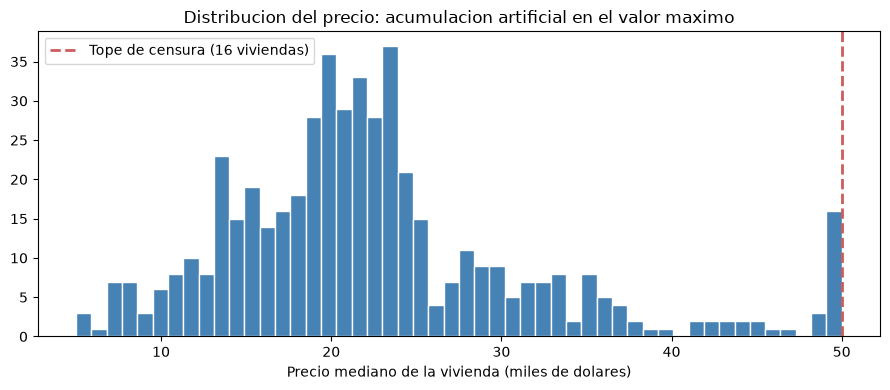

In [30]:
# El precio esta censurado: el censo trunco en 50 (miles de dolares) todas las viviendas que valian
# mas. Esas observaciones acotan el ajuste alcanzable en el extremo superior del rango de precios.
censuradas = (df_limpio['precio_mediano'] == 50).sum()
print(f'Viviendas con precio_mediano = 50 (valor maximo posible): {censuradas} de {len(df_limpio)}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_limpio['precio_mediano'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(50, color='indianred', ls='--', lw=2, label=f'Tope de censura ({censuradas} viviendas)')
ax.set_title('Distribucion del precio: acumulacion artificial en el valor maximo')
ax.set_xlabel('Precio mediano de la vivienda (miles de dolares)')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# 'limita_rio' es la unica variable categorica del dataset y ya viene codificada como dummy 0/1,
# por lo que no requiere ningun tipo de codificacion adicional. Se verifica ademas que esta
# fuertemente desbalanceada, lo que limita cuanto puede aportar al modelo.
print('Distribucion de limita_rio (1 = la zona limita con el rio Charles):')
print(df_limpio['limita_rio'].value_counts().to_string())
print(f'\nProporcion de zonas sobre el rio: {df_limpio["limita_rio"].mean():.1%}')
print(f'Precio mediano | no limita: {df_limpio[df_limpio.limita_rio == 0].precio_mediano.median():.1f} k$'
      f'  | limita: {df_limpio[df_limpio.limita_rio == 1].precio_mediano.median():.1f} k$')

Distribucion de limita_rio (1 = la zona limita con el rio Charles):
limita_rio
0.0    471
1.0     35

Proporcion de zonas sobre el rio: 6.9%
Precio mediano | no limita: 20.9 k$  | limita: 23.3 k$


Zonas con lotes_grandes = 0: 372 de 506 (73.5%)
criminalidad -> mediana: 0.26   maximo: 88.98   skew: 5.22


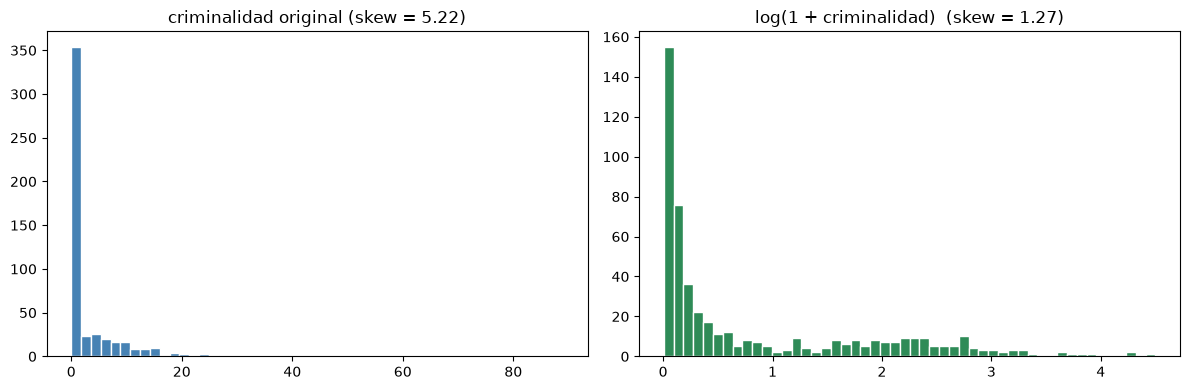

In [32]:
# 'lotes_grandes' esta concentrada en cero (la mayoria de las zonas no tiene lotes residenciales
# grandes) y 'criminalidad' es fuertemente asimetrica. Ambas son candidatas a transformacion antes
# del modelado; abajo se muestra el efecto de aplicar el logaritmo sobre la criminalidad.
print(f'Zonas con lotes_grandes = 0: {(df_limpio["lotes_grandes"] == 0).sum()} de {len(df_limpio)} '
      f'({(df_limpio["lotes_grandes"] == 0).mean():.1%})')
print(f'criminalidad -> mediana: {df_limpio["criminalidad"].median():.2f}   '
      f'maximo: {df_limpio["criminalidad"].max():.2f}   skew: {df_limpio["criminalidad"].skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_limpio['criminalidad'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'criminalidad original (skew = {df_limpio["criminalidad"].skew():.2f})')
axes[1].hist(np.log1p(df_limpio['criminalidad']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title(f'log(1 + criminalidad)  (skew = {np.log1p(df_limpio["criminalidad"]).skew():.2f})')
plt.tight_layout()
plt.show()